CLEANING DATA

1. INSTALL LIBRARIES (IF REQUIRED)

In [1]:
pip install "kagglehub[pandas-datasets]" pandas numpy matplotlib seaborn

2. IMPORT LIBRARIES AND LOAD THE KAGGLE DATASET

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset directly from Kaggle using KaggleHub
file_path = "dirty_cafe_sales.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training",
    file_path,
    pandas_kwargs={"encoding": "latin1"}
)

# Keep an unchanged copy of the original data
raw_df = df.copy()

print("Dataset loaded successfully!")
print(df.head())

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.
Dataset loaded successfully!
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


3. INITAL INSPECTION AND DATA QUALITY REPORT

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
print(df.head())

print("\nDescriptive Statistics:")
print(df.describe(include="all"))

# Identify common representations of invalid or missing data
invalid_values = ["", " ", "ERROR", "UNKNOWN", "N/A", "NULL"]

df = df.replace(invalid_values, np.nan)

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Count values that cannot be converted to numeric
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    converted = pd.to_numeric(df[col], errors="coerce")
    invalid_count = (df[col].notna() & converted.isna()).sum()
    print(f"Invalid numeric values in {col}: {invalid_count}")

Dataset Shape: (10000, 8)

Column Names:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']

Data Types:
Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

First 5 Records:
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2 

4. CREATE A REUSABLE DATA QUALITY REPORT

In [4]:
def data_quality_report(data):
    report = pd.DataFrame({
        "Data Type": data.dtypes.astype(str),
        "Missing Values": data.isnull().sum(),
        "Missing Percentage": (
            data.isnull().mean() * 100
        ).round(2),
        "Unique Values": data.nunique(dropna=True)
    })

    print("Rows:", len(data))
    print("Columns:", len(data.columns))
    print("Duplicate Rows:", data.duplicated().sum())
    print("\nColumn Quality Report:")
    print(report)

    return report


# Report on the original data, normalising known invalid markers
quality_before = data_quality_report(
    raw_df.replace(invalid_values, np.nan)
)

Rows: 10000
Columns: 8
Duplicate Rows: 0

Column Quality Report:
                 Data Type  Missing Values  Missing Percentage  Unique Values
Transaction ID      object               0                0.00          10000
Item                object             969                9.69              8
Quantity            object             479                4.79              5
Price Per Unit      object             533                5.33              6
Total Spent         object             502                5.02             17
Payment Method      object            3178               31.78              3
Location            object            3961               39.61              2
Transaction Date    object             460                4.60            365


5. HANDLE MISSING VALUES AND CORRECT DATATYPES

In [5]:
# Work on a separate cleaned copy
clean_df = raw_df.copy()

# Remove whitespace from column names and text values
clean_df.columns = clean_df.columns.str.strip()

text_cols = clean_df.select_dtypes(include="object").columns

for col in text_cols:
    clean_df[col] = clean_df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

# Convert common invalid markers into NaN
clean_df = clean_df.replace(
    ["", " ", "ERROR", "UNKNOWN", "N/A", "NULL"],
    np.nan
)

# Remove duplicate rows and record the number removed
duplicates_removed = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates().copy()

print("Duplicate rows removed:", duplicates_removed)

# Correct data types
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(
        clean_df[col], errors="coerce"
    )

clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce",
    format="mixed"
)

# Standardise categorical text
for col in ["Item", "Payment Method", "Location"]:
    clean_df[col] = clean_df[col].apply(
        lambda x: x.strip().title()
        if isinstance(x, str) else x
    )

# Missing item names cannot be reliably reconstructed
clean_df["Item"] = clean_df["Item"].fillna("Unknown Item")

# Missing categorical values get explicit labels
for col in ["Payment Method", "Location"]:
    clean_df[col] = clean_df[col].fillna("Unknown")

# Identify impossible values before imputing
clean_df.loc[clean_df["Quantity"] <= 0, "Quantity"] = np.nan
clean_df.loc[clean_df["Price Per Unit"] <= 0, "Price Per Unit"] = np.nan
clean_df.loc[clean_df["Total Spent"] < 0, "Total Spent"] = np.nan

# Impute quantity and price using item-level medians
# Use the global median if an item's median is unavailable
for col in ["Quantity", "Price Per Unit"]:
    item_medians = clean_df.groupby("Item")[col].transform("median")
    global_median = clean_df[col].median()

    clean_df[col] = clean_df[col].fillna(item_medians)
    clean_df[col] = clean_df[col].fillna(global_median)

# Recalculate total spent where quantity and price are known
calculated_total = (
    clean_df["Quantity"] * clean_df["Price Per Unit"]
)

clean_df["Total Spent"] = calculated_total.where(
    clean_df["Quantity"].notna()
    & clean_df["Price Per Unit"].notna(),
    clean_df["Total Spent"]
)

# If total spent remains missing, use its median as a fallback
total_median = clean_df["Total Spent"].median()

clean_df["Total Spent"] = clean_df["Total Spent"].fillna(
    total_median
)

# Correct final numeric dtypes
clean_df["Quantity"] = clean_df["Quantity"].round().astype("Int64")
clean_df["Price Per Unit"] = clean_df["Price Per Unit"].round(2)
clean_df["Total Spent"] = clean_df["Total Spent"].round(2)

# Transaction ID is an identifier, not a numeric measurement
clean_df["Transaction ID"] = clean_df["Transaction ID"].astype("string")

print("\nData types after cleaning:")
print(clean_df.dtypes)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nFirst 5 cleaned records:")
print(clean_df.head())

Duplicate rows removed: 0

Data types after cleaning:
Transaction ID      string[python]
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Missing values after cleaning:
Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

First 5 cleaned records:
  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee         2             2.0          4.0   
1    TXN_4977031    Cake         4             3.0         12.0   
2    TXN_4271903  Cookie         4             1.0          4.0   
3    TXN_7034554   Salad         2             5.0         10.0   
4    TXN_3160411  Coffee         2             2.0    

6. DETECT OUTLIERS USING THE IQR METHOD


Quantity
Lower Bound: -1.0
Upper Bound: 7.0
Outliers Detected: 0

Price Per Unit
Lower Bound: -1.0
Upper Bound: 7.0
Outliers Detected: 0

Total Spent
Lower Bound: -8.0
Upper Bound: 24.0
Outliers Detected: 256

Outlier Summary:
           Column   Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count
0        Quantity  2.0   4.0  2.0         -1.0          7.0              0
1  Price Per Unit  2.0   4.0  2.0         -1.0          7.0              0
2     Total Spent  4.0  12.0  8.0         -8.0         24.0            256


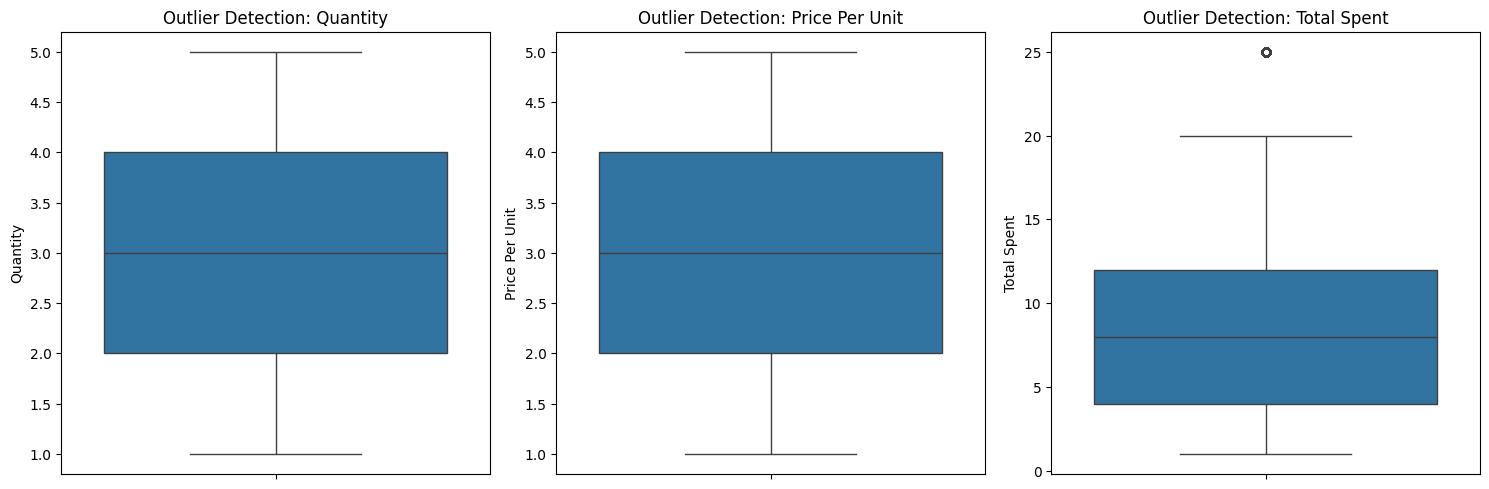

In [6]:
outlier_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

outlier_summary = []

for col in outlier_columns:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (clean_df[col] < lower_bound)
        | (clean_df[col] > upper_bound)
    )

    outlier_count = int(mask.sum())

    outlier_summary.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

    print(f"\n{col}")
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Outliers Detected:", outlier_count)

outlier_summary = pd.DataFrame(outlier_summary)

print("\nOutlier Summary:")
print(outlier_summary.round(2))

# Visualise outliers using boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, outlier_columns):
    sns.boxplot(y=clean_df[col].astype(float), ax=ax)
    ax.set_title(f"Outlier Detection: {col}")

plt.tight_layout()
plt.show()

7. BEFORE VS AFTER COMPARISON

In [7]:
# Apply the same invalid-marker treatment for a fair comparison
before_df = raw_df.replace(
    ["", " ", "ERROR", "UNKNOWN", "N/A", "NULL"],
    np.nan
)

# Check dtype correctness using expected data types
def dtype_accuracy(data):
    expected = {
        "Transaction ID": "string",
        "Item": "string",
        "Quantity": "Int64",
        "Price Per Unit": "float64",
        "Total Spent": "float64",
        "Payment Method": "string",
        "Location": "string",
        "Transaction Date": "datetime64[ns]"
    }

    correct = 0

    for col, expected_type in expected.items():
        if col in data.columns:
            if str(data[col].dtype) == expected_type:
                correct += 1

    return f"{correct}/{len(expected)} columns"


comparison = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Column Count",
        "Missing Values",
        "Duplicate Rows",
        "Data Type Accuracy"
    ],
    "Before Cleaning": [
        len(before_df),
        len(before_df.columns),
        int(before_df.isnull().sum().sum()),
        int(before_df.duplicated().sum()),
        dtype_accuracy(before_df)
    ],
    "After Cleaning": [
        len(clean_df),
        len(clean_df.columns),
        int(clean_df.isnull().sum().sum()),
        int(clean_df.duplicated().sum()),
        dtype_accuracy(clean_df)
    ]
})

print(comparison.to_string(index=False))

            Metric Before Cleaning After Cleaning
         Row Count           10000          10000
      Column Count               8              8
    Missing Values           10082            460
    Duplicate Rows               0              0
Data Type Accuracy     0/8 columns    5/8 columns


8. FINAL VALIDATION

In [8]:
print("FINAL DATA VALIDATION")
print("=" * 40)

print("Final Shape:", clean_df.shape)

print("\nFinal Data Types:")
print(clean_df.dtypes)

print("\nRemaining Missing Values:")
print(clean_df.isnull().sum())

print("\nRemaining Duplicate Rows:", clean_df.duplicated().sum())

print("\nNumerical Summary:")
print(clean_df.describe().round(2))

# Verify transaction total consistency
expected_total = (
    clean_df["Quantity"].astype(float)
    * clean_df["Price Per Unit"]
)

mismatch_count = (
    (clean_df["Total Spent"] - expected_total).abs() > 0.02
).sum()

print("\nTotal Spent consistency mismatches:", int(mismatch_count))

FINAL DATA VALIDATION
Final Shape: (10000, 8)

Final Data Types:
Transaction ID      string[python]
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Remaining Missing Values:
Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

Remaining Duplicate Rows: 0

Numerical Summary:
       Quantity  Price Per Unit  Total Spent               Transaction Date
count   10000.0        10000.00     10000.00                           9540
mean       3.03            2.95         8.94  2023-07-01 23:00:31.698113280
min         1.0            1.00         1.00            2023-01-01 00:00:00
25%         2.0            2.00         4.00            

9. SAVING THE CLEANED DATASET

In [9]:
output_file = "cleaned_cafe_sales.csv"

clean_df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved successfully as: {output_file}")

Cleaned dataset saved successfully as: cleaned_cafe_sales.csv
